## 0. Install packages
To run pytorch locally, we recommend you have at least a 20 series GPU or later (2060, 3080, etc.). You can install pytorch by following the instructions on the [official website](https://pytorch.org/get-started/locally/).
A command you can use quickly would be:
```
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu128
```
We highly recommend you to check the version compatibility of your CUDA version and your GPU before running.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

# Imports from scikit-learn
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(f"PyTorch Version: {torch.__version__}")

PyTorch Version: 2.8.0+cu128


## 1\. PyTorch Tensors 🧱

A **tensor** is the fundamental data structure in PyTorch. It's essentially a multi-dimensional array, very similar to a NumPy array. Tensors can be used on a GPU to accelerate computing, which is crucial for deep learning.

### Creating Tensors

You can create tensors in several ways.



In [2]:
# Create a tensor from a Python list
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)
print(f"Tensor from list:\n {x_data}\n")

# Create a tensor from a NumPy array
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(f"Tensor from NumPy array:\n {x_np}\n")

# Create tensors with random values or constants
shape = (2, 3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor:\n {rand_tensor}\n")
print(f"Ones Tensor:\n {ones_tensor}\n")
print(f"Zeros Tensor:\n {zeros_tensor}")



Tensor from list:
 tensor([[1, 2],
        [3, 4]])

Tensor from NumPy array:
 tensor([[1, 2],
        [3, 4]])

Random Tensor:
 tensor([[0.2890, 0.2709, 0.6111],
        [0.8539, 0.2698, 0.9220]])

Ones Tensor:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])

Zeros Tensor:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### Tensor Attributes

Tensors have attributes that describe their shape, datatype, and the device where they are stored.

In [3]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


### Tensor Operations

PyTorch offers a comprehensive library of operations, including arithmetic, linear algebra, matrix manipulation, and more. The syntax is very similar to NumPy.

In [4]:
# Create two tensors
tensor = torch.ones(2, 2)
tensor2 = torch.tensor([[2., 3], [4, 5]])
# tensor2 = torch.tensor([[2, 3], [4, 5]])
# tensor2 = torch.tensor([[2, 3], [4, 5]], dtype=torch.float32) # Specify dtype to match tensor

# Arithmetic operations
sum_tensor = tensor + tensor2 # or torch.add(tensor, tensor2)
prod_tensor = tensor * tensor2 # Element-wise product
matmul_tensor = tensor @ tensor2.T # Matrix multiplication, .T is transpose

print(f"Sum of tensors:\n {sum_tensor}\n")
print(f"Element-wise product:\n {prod_tensor}\n")
print(f"Matrix multiplication:\n {matmul_tensor}\n")

# In-place operations (modify the tensor)
print(f"Original tensor:\n {tensor}\n")
tensor.add_(5) # The trailing '_' indicates an in-place operation
print(f"Tensor after in-place add:\n {tensor}")

Sum of tensors:
 tensor([[3., 4.],
        [5., 6.]])

Element-wise product:
 tensor([[2., 3.],
        [4., 5.]])

Matrix multiplication:
 tensor([[5., 9.],
        [5., 9.]])

Original tensor:
 tensor([[1., 1.],
        [1., 1.]])

Tensor after in-place add:
 tensor([[6., 6.],
        [6., 6.]])


### GPU Acceleration 🚀

One of PyTorch's key features is its ability to run on GPUs. You can move a tensor to a GPU (if available) using the `.to()` method.

In [5]:
# Check if CUDA (GPU support) is available
device = "cuda" if torch.cuda.is_available() else "cpu"
# Get device name
if device == "cuda":
    device_name = torch.cuda.get_device_name(0)
    print(f"CUDA is available. Using GPU: {device_name}")
else:
    device_name = "cpu"
    print("CUDA is not available. Using CPU.")
print(f"Using {device_name} device")

# Create a tensor and move it to the selected device
x = torch.rand(3, 3)
x = x.to(device)
print(x)
# Note: If you run this without a GPU, it will just stay on the CPU.
# Any operations on 'x' will now be executed on the GPU!

CUDA is available. Using GPU: NVIDIA GeForce RTX 4090 Laptop GPU
Using NVIDIA GeForce RTX 4090 Laptop GPU device
tensor([[0.3938, 0.5645, 0.6550],
        [0.2880, 0.7143, 0.7852],
        [0.1681, 0.7675, 0.6365]], device='cuda:0')


## 2\. Autograd: Automatic Differentiation ⚙️

`torch.autograd` is PyTorch’s automatic differentiation engine. When you perform operations on tensors, it builds a **computational graph**. This graph tracks how to compute the gradient of any output with respect to its inputs.

To enable this, you set `requires_grad=True` on a tensor.

Let's see a simple example. Suppose we have the function $y = x^2$. We want to find the gradient $\\frac{dy}{dx}$ at $x=3$. We know the answer is $2x$, so at $x=3$, the gradient should be 6.

In [6]:
# Create a tensor and set requires_grad=True to track computation
x = torch.tensor(3.0, requires_grad=True)
print(f"x = {x}")

# Define a simple operation
y = x**2
print(f"y = x^2 = {y}")

# Use autograd to compute the gradients
# .backward() computes the gradient of 'y' with respect to all tensors
# it depends on (in this case, just 'x')
y.backward()

# The gradient is stored in the .grad attribute of the tensor
print(f"dy/dx at x=3 is: {x.grad}")

x = 3.0
y = x^2 = 9.0
dy/dx at x=3 is: 6.0


This becomes incredibly powerful for neural networks, where we need to compute the gradients of the loss function with respect to all model parameters (weights and biases).

## 3\. Building a Neural Network with `torch.nn` 🧠

PyTorch provides the `torch.nn` module to help us create and train neural networks. A model is typically built as a class that inherits from `nn.Module`.

A `nn.Module` contains layers and a `forward()` method that specifies how data flows through them.

Let's build a simple feed-forward network to predict a single output value from a 10-dimensional input vector.
Our network will have:

  * An input layer of size 10.
  * A hidden layer of size 32 with a ReLU activation function.
  * An output layer of size 1.

<!-- end list -->



In [7]:
# Define the model by subclassing nn.Module
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(8, 64), # Input features: 8
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)      # Output features: 1
        )

    def forward(self, x):
        return self.layers(x)

# Create an instance of the model and move it to the device
model = SimpleNet().to(device)
print(model)

# You can also inspect the model's parameters (weights and biases)
print("Model Parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data.shape)

SimpleNet(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)
Model Parameters:
layers.0.weight torch.Size([64, 8])
layers.0.bias torch.Size([64])
layers.2.weight torch.Size([32, 64])
layers.2.bias torch.Size([32])
layers.4.weight torch.Size([1, 32])
layers.4.bias torch.Size([1])


We can test our untrained model by passing some random data through it.

In [8]:
# Create a random input tensor of size (batch_size, input_features)
input_data = torch.rand(1, 8).to(device) # Batch size of 1, input features of 8

# Get the model's prediction
prediction = model(input_data)
print(f"Model prediction for random input: {prediction}")

Model prediction for random input: tensor([[0.2589]], device='cuda:0', grad_fn=<AddmmBackward0>)


## 4\. Datasets and DataLoaders 📦

So far, we've used simple, manually created tensors. For real-world projects, you'll work with large datasets. PyTorch's `Dataset` and `DataLoader` utilities provide a powerful and efficient way to handle this.

  * **`Dataset`**: An abstract class for storing your data and labels. You can create your own custom dataset by inheriting from it. A custom dataset must implement three methods: `__init__`, `__len__`, and `__getitem__`.
  * **`DataLoader`**: Wraps a `Dataset` and provides an iterable to easily access the data in **batches**. It also handles shuffling, parallel data loading, and more.


Here, we'll load the California Housing data using `scikit-learn`. A crucial step in many regression tasks is feature scaling, which standardizes features to have a mean of 0 and a standard deviation of 1. This helps the network train more effectively.

In [9]:
# 1. Load the dataset
housing = fetch_california_housing()
X, y = housing.data, housing.target

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Convert NumPy arrays to PyTorch Tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

#### Creating a Custom Dataset and DataLoader
Now, we'll wrap our tensors in a custom `Dataset` and then use `DataLoader` to create batches.

In [10]:
# 1. Create a custom Dataset class
class HousingDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# 2. Create Dataset instances
train_dataset = HousingDataset(X_train, y_train)
test_dataset = HousingDataset(X_test, y_test)

# 3. Create DataLoaders
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

# Let's check a batch
features_batch, labels_batch = next(iter(train_dataloader))
print(f"Shape of features batch: {features_batch.shape}")
print(f"Shape of labels batch: {labels_batch.shape}")

Shape of features batch: torch.Size([64, 8])
Shape of labels batch: torch.Size([64, 1])


Using a `DataLoader` makes your training loop clean and memory-efficient, as it only loads one batch of data into memory at a time.

## 5\. Training a Model 🏋️‍♀️

Now we'll update our training process to use the `DataLoader`. The training loop will now iterate over the `DataLoader` instead of using the entire dataset at once. This is standard practice.

1.  **Loss Function:** Measures how far the model's output is from the true target.
2.  **Optimizer:** Implements an algorithm (like Stochastic Gradient Descent) to update the model's weights.
3.  **Training Loop:** The process of iterating through the `DataLoader`, feeding batches to the model, and updating weights.

<!-- end list -->

Epoch 1: Test Loss = 0.5600
Epoch 2: Test Loss = 0.4301
Epoch 3: Test Loss = 0.4094
Epoch 4: Test Loss = 0.3822
Epoch 5: Test Loss = 0.3733
Epoch 6: Test Loss = 0.3815
Epoch 7: Test Loss = 0.3489
Epoch 8: Test Loss = 0.3464
Epoch 9: Test Loss = 0.3335
Epoch 10: Test Loss = 0.3321
Epoch 11: Test Loss = 0.3282
Epoch 12: Test Loss = 0.3234
Epoch 13: Test Loss = 0.3151
Epoch 14: Test Loss = 0.3159
Epoch 15: Test Loss = 0.3081
Epoch 16: Test Loss = 0.3425
Epoch 17: Test Loss = 0.3035
Epoch 18: Test Loss = 0.2979
Epoch 19: Test Loss = 0.2945
Epoch 20: Test Loss = 0.3041
Done!


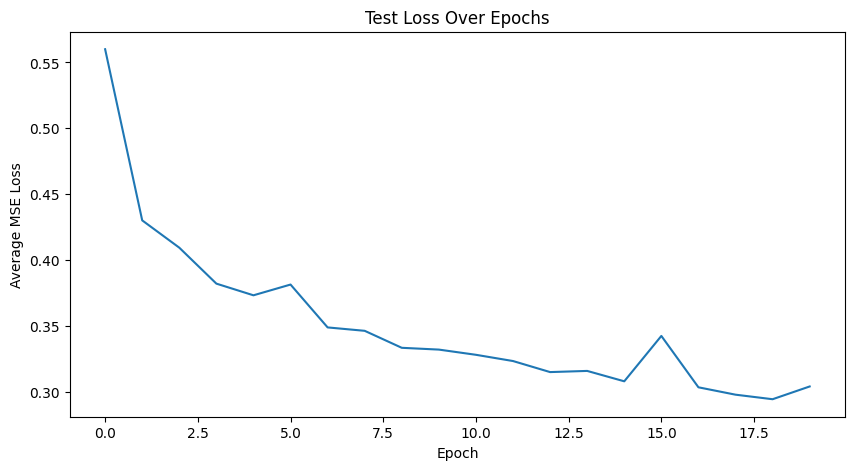

In [11]:
# --- 1. Define Loss Function and Optimizer ---
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# --- 2. Define the Training and Test Loops ---
def train_loop(dataloader, model, loss_fn, optimizer):
    model.train() # Set the model to training mode
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

def test_loop(dataloader, model, loss_fn):
    model.eval() # Set the model to evaluation mode
    test_loss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
    test_loss /= len(dataloader)
    return test_loss # Return the loss for plotting

# --- 3. Run the training process and store loss history ---
epochs = 20
# NEW: Create a list to store the loss history
loss_history = []

for t in range(epochs):

    train_loop(train_dataloader, model, loss_fn, optimizer)
    # NEW: Capture the returned loss value
    epoch_loss = test_loop(test_dataloader, model, loss_fn)
    print(f"Epoch {t+1}: Test Loss = {epoch_loss:.4f}")
    loss_history.append(epoch_loss)

print("Done!")

# --- 4. Plot the loss diagram ---
# NEW: Add the plotting cell
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.title("Test Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Average MSE Loss")
plt.show()

As you can see, the loss steadily decreases, which means our model is learning\!



## 6\. Saving and Loading Models 💾

After training your model, you'll want to save it so you can use it later without having to retrain. The common PyTorch convention is to save the model's **state dictionary** (`state_dict`), which contains all of its learned weights and biases.

### Saving the Model

Saving the state dictionary is a simple one-liner. The file is typically saved with a `.pth` or `.pt` extension.

In [12]:
# Define the path to save the model
MODEL_PATH = "simple_net_weights.pth"

# Save the model's learned parameters
torch.save(model.state_dict(), MODEL_PATH)

print(f"Model saved to {MODEL_PATH}")

Model saved to simple_net_weights.pth


### Loading the Model

To load the model, you first need to create an instance of the model architecture, and then you can load the saved state dictionary into it.

In [13]:
# Create a new instance of the model
loaded_model = SimpleNet().to(device)

# Load the saved weights
loaded_model.load_state_dict(torch.load(MODEL_PATH))

# Set the model to evaluation mode
loaded_model.eval()

# Let's test the loaded model on a few samples from the test set
with torch.no_grad():
    X_sample, y_sample = next(iter(test_dataloader))
    X_sample, y_sample = X_sample.to(device), y_sample.to(device)

    predictions = loaded_model(X_sample)

    print("Predicted   |   True")
    print("----------------------")
    for i in range(5):
      pred = predictions[i].item()
      true = y_sample[i].item()
      print(f"{pred:^11.4f} | {true:^10.4f}")

Predicted   |   True
----------------------
  0.5884    |   0.4770  
  0.9448    |   0.4580  
  4.5867    |   5.0000  
  2.4852    |   2.1860  
  3.0890    |   2.7800  


As you can see, the loaded model makes a reasonable prediction, demonstrating that the learned weights were successfully restored.

## 7\. Conclusion & Next Steps 🎉

Congratulations\! You've just built and trained your first neural network in PyTorch using standard data handling practices.

We've covered:

  * **Tensors:** The core data structure.
  * **Autograd:** The engine for automatic differentiation.
  * **`nn.Module`:** The blueprint for creating models.
  * **`Dataset` & `DataLoader`:** For efficiently preparing and loading data.
  * **Training Loop:** The process of using a loss function and optimizer to train a model.
  * **Saving & Loading:** For persisting and reusing your trained models.

This is just the beginning. From here, you can explore:

  * **Torchvision:** A library with popular datasets, model architectures, and image transformations for computer vision.
  * **Convolutional Neural Networks (CNNs):** For image processing tasks.
  * **Recurrent Neural Networks (RNNs):** For sequence data like text or time series.

Happy coding\!